In [2]:
import os
import shutil

zip_dosyasi = "archive.zip"

if os.path.exists(zip_dosyasi):
    print(f"'{zip_dosyasi}' bulundu. Eski klasörler temizleniyor ve yeniden açılıyor...")

    if os.path.exists('train'): shutil.rmtree('train')
    if os.path.exists('test'): shutil.rmtree('test')

    !unzip -q {zip_dosyasi}

    if os.path.exists('train') and os.path.exists('test'):
        train_dir = 'train'
        val_dir = 'test'
        print("Klasör yapısı bulundu: 'train' ve 'test' klasörleri ana dizinde.")
    else:
        print("Ana dizinde klasör bulunamadı, alt dizinler aranıyor...")
        for root, dirs, files in os.walk("."):
            if "train" in dirs and "test" in dirs:
                train_dir = os.path.join(root, "train")
                val_dir = os.path.join(root, "test")
                print(f"Klasörler bulundu: {train_dir} ve {val_dir}")
                break
else:
    print(f"HATA: '{zip_dosyasi}' bulunamadı. Dosya adını doğru yazdığınızdan emin olun.")

'archive.zip' bulundu. Eski klasörler temizleniyor ve yeniden açılıyor...
Klasör yapısı bulundu: 'train' ve 'test' klasörleri ana dizinde.


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Kullanılan cihaz: {device}")

Kullanılan cihaz: cuda


In [4]:
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

if 'train_dir' in locals() and os.path.exists(train_dir):
    print(f"Veriler şu klasörden okunuyor: {train_dir}")

    train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms['train'])
    val_dataset = datasets.ImageFolder(val_dir, transform=data_transforms['val'])

    class_names = train_dataset.classes
    print(f"Sınıflar: {class_names}")

    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)
    print("DataLoader hazır!")
else:
    print("HATA: Train klasörü bulunamadı. Lütfen önce Hücre 1'i çalıştırın.")

Veriler şu klasörden okunuyor: train
Sınıflar: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
DataLoader hazır!


In [5]:
print("GoogLeNet indiriliyor...")
model = models.googlenet(weights=models.GoogLeNet_Weights.DEFAULT)

num_classes = len(class_names)
print(f"Tespit edilen sınıf sayısı: {num_classes}")

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_classes)

model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

GoogLeNet indiriliyor...
Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:00<00:00, 67.8MB/s]


Tespit edilen sınıf sayısı: 7


In [6]:
def train_model(num_epochs=5):
    print(f"Eğitim başlıyor... (Epoch Sayısı: {num_epochs})")
    history = {'loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)

            if isinstance(outputs, tuple):
                logits = outputs[0]
            else:
                logits = outputs

            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            if (i+1) % 100 == 0:
                print(f"Epoch [{epoch+1}/{num_epochs}], Adım [{i+1}], Loss: {loss.item():.4f}")

        epoch_loss = running_loss / len(train_loader)

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_acc = 100 * correct / total
        print(f"--- Epoch {epoch+1} Bitti | Train Loss: {epoch_loss:.4f} | Val Acc: {val_acc:.2f}% ---")

        history['loss'].append(epoch_loss)
        history['val_acc'].append(val_acc)

    return history

Eğitim başlıyor... (Epoch Sayısı: 3)
Epoch [1/3], Adım [100], Loss: 1.3096
Epoch [1/3], Adım [200], Loss: 1.0492
Epoch [1/3], Adım [300], Loss: 1.1167
Epoch [1/3], Adım [400], Loss: 1.2745
--- Epoch 1 Bitti | Train Loss: 1.1835 | Val Acc: 56.24% ---
Epoch [2/3], Adım [100], Loss: 0.9596
Epoch [2/3], Adım [200], Loss: 0.9068
Epoch [2/3], Adım [300], Loss: 1.0070
Epoch [2/3], Adım [400], Loss: 1.0032
--- Epoch 2 Bitti | Train Loss: 1.0102 | Val Acc: 61.28% ---
Epoch [3/3], Adım [100], Loss: 0.9217
Epoch [3/3], Adım [200], Loss: 0.8483
Epoch [3/3], Adım [300], Loss: 0.9208
Epoch [3/3], Adım [400], Loss: 0.8826
--- Epoch 3 Bitti | Train Loss: 0.9376 | Val Acc: 63.85% ---


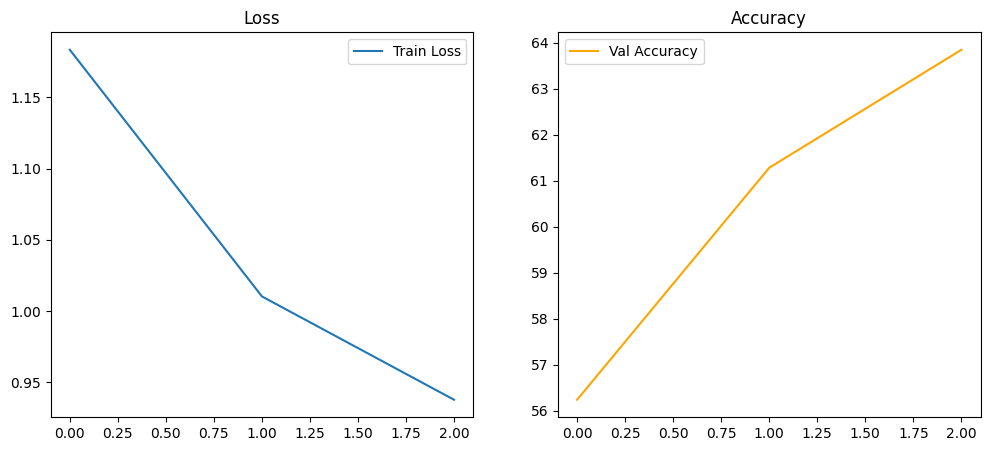

Model kaydedildi.


In [7]:
if 'train_loader' in locals():
    history = train_model(num_epochs=3)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['loss'], label='Train Loss')
    plt.title('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['val_acc'], label='Val Accuracy', color='orange')
    plt.title('Accuracy')
    plt.legend()
    plt.show()

    torch.save(model.state_dict(), 'base_model_googlenet_folder.pth')
    print("Model kaydedildi.")

Grafikler için tahminler toplanıyor...


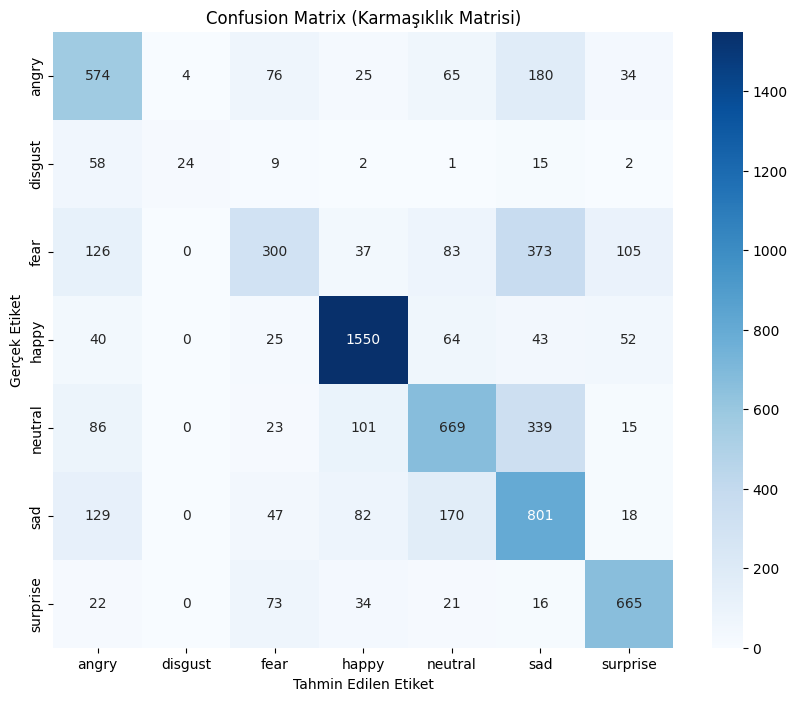

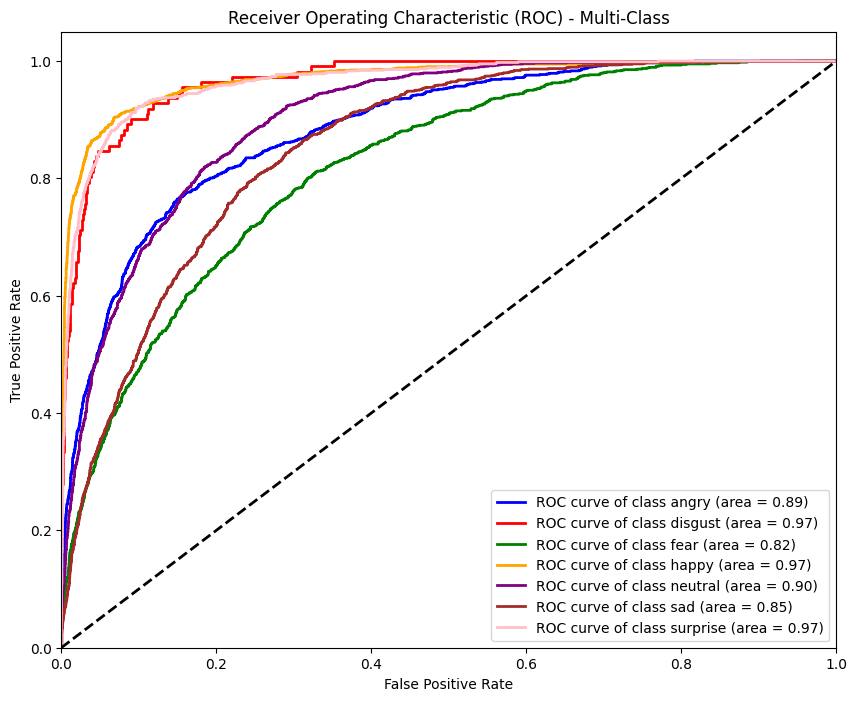

In [8]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

if 'class_names' not in locals():
    class_names = ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']

def plot_evaluation_metrics(model, val_loader, class_names):
    model.eval()
    y_true = []
    y_pred = []
    y_score = []

    print("Grafikler için tahminler toplanıyor...")

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            probs = torch.nn.functional.softmax(outputs, dim=1)

            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_score.extend(probs.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_score = np.array(y_score)

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix (Karmaşıklık Matrisi)')
    plt.ylabel('Gerçek Etiket')
    plt.xlabel('Tahmin Edilen Etiket')
    plt.show()

    n_classes = len(class_names)
    y_true_bin = label_binarize(y_true, classes=range(n_classes))

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(10, 8))
    colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink']

    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label='ROC curve of class {0} (area = {1:0.2f})'
                 ''.format(class_names[i], roc_auc[i]))

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) - Multi-Class')
    plt.legend(loc="lower right")
    plt.show()

if 'val_loader' in locals() and 'model' in locals():
    if 'train_dataset' in locals() and hasattr(train_dataset, 'classes'):
        plot_evaluation_metrics(model, val_loader, train_dataset.classes)
    else:

        labels_list = ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']
        plot_evaluation_metrics(model, val_loader, labels_list)
else:
    print("HATA: Model veya DataLoader bulunamadı.")